# Residential Mobility Analysis — Nantes Métropole
## Source: INSEE Population Census 2020 (`FD_MIGCOM_2020`)

This notebook reproduces the analyses from **Mission 1** of the internship report. All figures are produced **exclusively**  from INSEE data.


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import seaborn as sns
import geopandas as gpd
import plotly.graph_objects as go
import plotly.express as px
from scipy import stats
import urllib.request
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
OUTPUT_DIR = '.'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Imports OK')

Imports OK


## 2. Nantes Métropole Communes

In [2]:
NM_COMMUNES = {
    '44009': 'Basse-Goulaine',
    '44018': 'Bouaye',
    '44020': 'Bouguenais',
    '44024': 'Brains',
    '44026': 'Carquefou',
    '44035': 'La Chapelle-sur-Erdre',
    '44047': 'Couëron',
    '44074': 'Indre',
    '44094': 'Mauves-sur-Loire',
    '44101': 'La Montagne',
    '44109': 'Nantes',
    '44114': 'Orvault',
    '44120': 'Le Pellerin',
    '44143': 'Rezé',
    '44150': 'Saint-Aignan-Grandlieu',
    '44162': 'Saint-Herblain',
    '44166': 'Saint-Jean-de-Boiseau',
    '44171': 'Saint-Léger-les-Vignes',
    '44172': 'Sainte-Luce-sur-Loire',
    '44190': 'Saint-Sébastien-sur-Loire',
    '44194': 'Sautron',
    '44198': 'Les Sorinières',
    '44204': 'Thouaré-sur-Loire',
    '44215': 'Vertou'}

# Île-de-France departments
IDF_DEPTS = {'75', '77', '78', '91', '92', '93', '94', '95'}

print(f'{len(NM_COMMUNES)} Nantes Métropole communes defined.')

24 Nantes Métropole communes defined.


## 3. Data Loading (Chunked)

> The file `FD_MIGCOM_2020.csv` must be in the same directory as this notebook. It contains ~19 million rows (all of France). The file is read in chunks of 500,000 rows to avoid loading the full ~1.8 GB into memory at once.


In [3]:
DATA_PATH = 'FD_MIGCOM_2020.csv'

NM_CODES  = set(NM_COMMUNES.keys())
IDF_DEPTS = {'75', '77', '78', '91', '92', '93', '94', '95'}

# ── Chunked reading to save RAM ───────────────────────────────────────────
# The file is ~1.8 GB / 19.5 M rows. Read in 500k-row chunks:
# only keep rows relevant to NM (COMMUNE or DCRAN in NM, IRAN != '1').
CHUNK_SIZE = 500_000
chunks_enter, chunks_leave = [], []
total_rows, total_movers = 0, 0

print('Reading INSEE file in chunks...')
for i, chunk in enumerate(pd.read_csv(
        DATA_PATH, sep=';', dtype=str, chunksize=CHUNK_SIZE, low_memory=False)):
    for col in ['COMMUNE', 'DCRAN', 'IRAN']:
        chunk[col] = chunk[col].str.strip()
    chunk['IPONDI'] = pd.to_numeric(chunk['IPONDI'], errors='coerce')
    chunk['NPERR']  = pd.to_numeric(chunk['NPERR'],  errors='coerce')
    movers = chunk[chunk['IRAN'] != '1']
    total_rows   += len(chunk)
    total_movers += len(movers)
    e = movers[movers['COMMUNE'].isin(NM_CODES)]
    l = movers[movers['DCRAN'].isin(NM_CODES)]
    if not e.empty: chunks_enter.append(e)
    if not l.empty: chunks_leave.append(l)
    if (i+1) % 5 == 0:
        print(f'  chunk {i+1} — {total_rows:,} rows read...', end='\r')

print(f'\nFile fully read: {total_rows:,} rows | {total_movers:,} movers (IRAN!=1)')

Reading INSEE file in chunks...
  chunk 40 — 19,501,103 rows read...
File fully read: 19,501,103 rows | 2,335,254 movers (IRAN!=1)


In [4]:
# Inspect key variables on a 100,000-row sample
print('Loading sample for variable inspection...')
df_sample = pd.read_csv(DATA_PATH, sep=';', dtype=str, nrows=100_000, low_memory=False)
for col in ['COMMUNE', 'DCRAN', 'IRAN']:
    df_sample[col] = df_sample[col].str.strip()
df_sample['NPERR'] = pd.to_numeric(df_sample['NPERR'], errors='coerce')

print('IRAN — unique values:')
print(df_sample['IRAN'].value_counts())
print()
print('NPERR — distribution (top 8):')
print(df_sample['NPERR'].value_counts().sort_index().head(8))
print()
print('DCRAN — non-standard values (sample):')
mask_nonstandard = ~df_sample['DCRAN'].str.match(r'^\d{5}$', na=False)
print(df_sample.loc[mask_nonstandard, 'DCRAN'].value_counts().head(10))

Loading sample for variable inspection...
IRAN — unique values:
IRAN
1    88042
3     4116
2     3465
4     1940
5     1382
9      495
0      282
8      204
6       58
7       16
Name: count, dtype: int64

NPERR — distribution (top 8):
NPERR
1.0    16140
2.0    28309
3.0    17763
4.0    21210
5.0    10053
6.0     4620
Name: count, dtype: int64

DCRAN — non-standard values (sample):
DCRAN
2A004    2
2A247    2
2A212    1
Name: count, dtype: int64


## 4. Sub-dataset Assembly

Following the methodology from the internship:
- **IRAN filter**: only individuals who actually moved (`IRAN != '1'`) are kept.
- **NM_enter** : moves *towards* Nantes Métropole (`COMMUNE ∈ NM`).
- **NM_leave** : moves *from* Nantes Métropole (`DCRAN ∈ NM`).
- **NM_intra** : moves *within* Nantes Métropole (`COMMUNE ∈ NM` AND `DCRAN ∈ NM`).


In [5]:
# Assemble sub-datasets from loaded chunks
NM_enter        = pd.concat(chunks_enter, ignore_index=True) if chunks_enter else pd.DataFrame()
NM_leave        = pd.concat(chunks_leave, ignore_index=True) if chunks_leave else pd.DataFrame()
NM_intra        = NM_enter[NM_enter['DCRAN'].isin(NM_CODES)].copy()
NM_enter_strict = NM_enter[~NM_enter['DCRAN'].isin(NM_CODES)].copy()
NM_leave_strict = NM_leave[~NM_leave['COMMUNE'].isin(NM_CODES)].copy()

print(f'NM_enter   (all inbound moves)       : {NM_enter["IPONDI"].sum():>10,.0f} persons')
print(f'NM_leave   (all outbound moves)      : {NM_leave["IPONDI"].sum():>10,.0f} persons')
print(f'NM_intra   (intra-NM moves)          : {NM_intra["IPONDI"].sum():>10,.0f} persons')
print(f'Strict entries (outside NM to NM)    : {NM_enter_strict["IPONDI"].sum():>10,.0f} persons')
print(f'Strict exits   (NM to outside NM)    : {NM_leave_strict["IPONDI"].sum():>10,.0f} persons')

NM_enter   (all inbound moves)       :     98,672 persons
NM_leave   (all outbound moves)      :     91,827 persons
NM_intra   (intra-NM moves)          :     60,381 persons
Strict entries (outside NM to NM)    :     38,291 persons
Strict exits   (NM to outside NM)    :     31,445 persons


## 5. Global Statistics by Commune

In [6]:
# Total entries and exits per commune (all mobility types)
entries_total = NM_enter.groupby('COMMUNE')['IPONDI'].sum().rename('entries_total')
exits_total   = NM_leave.groupby('DCRAN')['IPONDI'].sum().rename('exits_total')
entries_intra = NM_intra.groupby('COMMUNE')['IPONDI'].sum().rename('entries_intra')
exits_intra   = NM_intra.groupby('DCRAN')['IPONDI'].sum().rename('exits_intra')

commune_stats = pd.DataFrame({'code': list(NM_CODES)})
commune_stats = commune_stats.set_index('code')
commune_stats = commune_stats.join(entries_total).join(exits_total)\
                             .join(entries_intra).join(exits_intra)
commune_stats = commune_stats.fillna(0)
commune_stats['name'] = commune_stats.index.map(NM_COMMUNES)
commune_stats['attractivity_ratio'] = (commune_stats['entries_intra'] / commune_stats['exits_intra'].replace(0, np.nan))

print(commune_stats[['name','entries_total','exits_total','entries_intra','exits_intra','attractivity_ratio']]
      .sort_values('entries_total', ascending=False).to_string())

                            name  entries_total   exits_total  entries_intra   exits_intra  attractivity_ratio
code                                                                                                          
44109                     Nantes   58281.041419  55798.012744   33808.400549  37101.291333            0.911246
44162             Saint-Herblain    6622.572711   5655.706685    4469.761424   4287.767534            1.042445
44143                       Rezé    5388.349281   5013.692283    3619.584996   3464.491186            1.044767
44190  Saint-Sébastien-sur-Loire    3330.648282   3160.920497    2138.607742   1971.850892            1.084569
44114                    Orvault    3036.211658   2737.829818    2078.533888   1869.337272            1.111910
44026                  Carquefou    2760.513444   2456.683455    1513.154853   1483.412255            1.020050
44215                     Vertou    2645.978372   2300.885129    1604.293201   1353.920969            1.184924
4

## 6. Distribution by Household Size
Distribution of mobility volume by number of persons per household (`NPERR`).

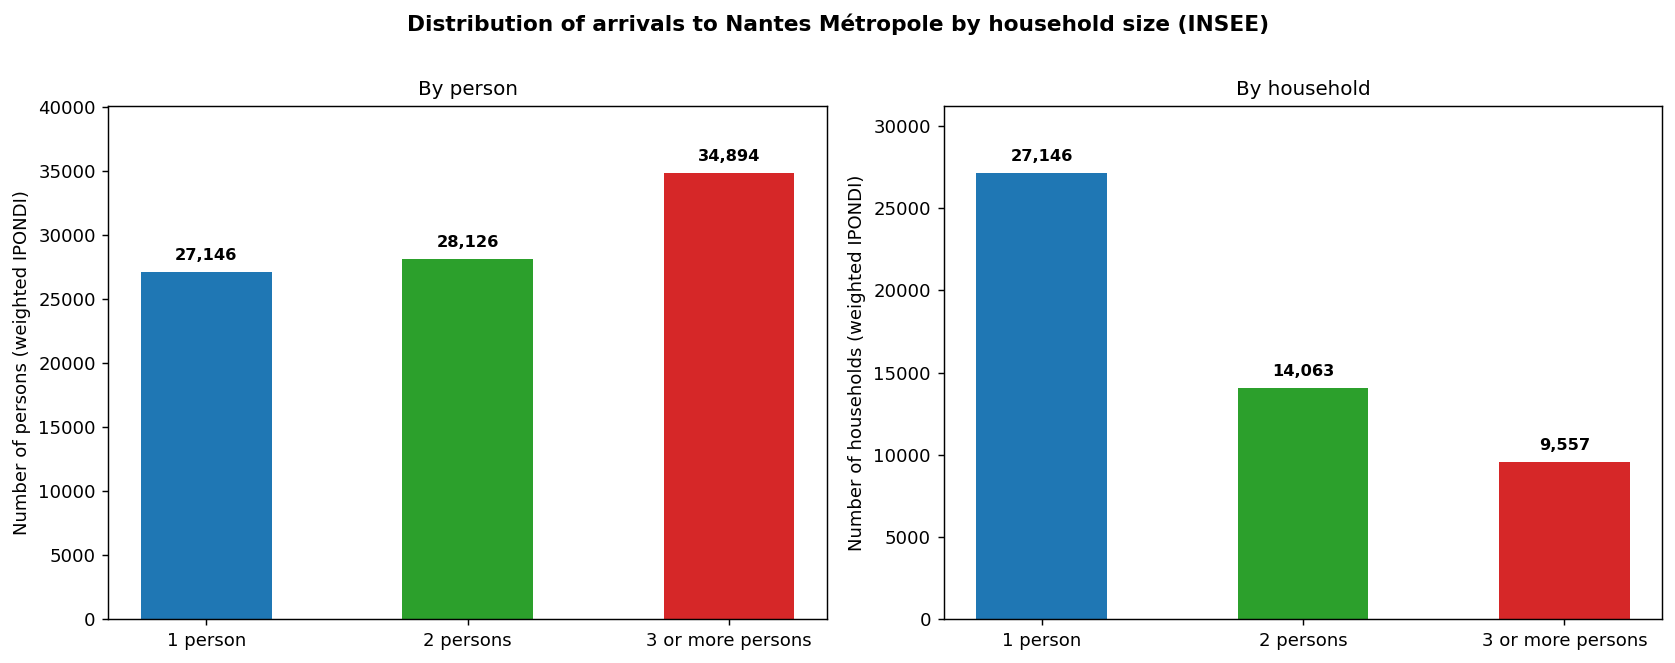

Proportions (persons)   : {'1 person': 30.1, '2 persons': 31.2, '3 or more persons': 38.7}
Proportions (households): {'1 person': 53.5, '2 persons': 27.7, '3 or more persons': 18.8}


In [7]:
def nperr_group(n):
    if n == 1:  return '1 person'
    elif n == 2: return '2 persons'
    else:        return '3 or more persons'

tmp = NM_enter.dropna(subset=['NPERR']).copy()
tmp['group'] = tmp['NPERR'].apply(nperr_group)
tmp['IPONDI_households'] = tmp['IPONDI'] / tmp['NPERR'].clip(upper=6)

order  = ['1 person', '2 persons', '3 or more persons']
colors = ['#1f77b4', '#2ca02c', '#d62728']

dist_persons    = tmp.groupby('group')['IPONDI'].sum().reindex(order)
dist_households = tmp.groupby('group')['IPONDI_households'].sum().reindex(order)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, dist, ylabel, subtitle in zip(axes, [dist_persons, dist_households],
    ['Number of persons (weighted IPONDI)', 'Number of households (weighted IPONDI)'],['By person', 'By household']):
    bars = ax.bar(order, dist.values, color=colors, width=0.5)
    for bar, val in zip(bars, dist.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + dist.max() * 0.02, 
                f'{val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(subtitle, fontsize=11)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, dist.max() * 1.15)

fig.suptitle('Distribution of arrivals to Nantes Métropole by household size (INSEE)', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/nperr_distribution_INSEE.png', dpi=150, bbox_inches='tight'); plt.show()

print('Proportions (persons)   :', (dist_persons    / dist_persons.sum()    * 100).round(1).to_dict())
print('Proportions (households):', (dist_households / dist_households.sum() * 100).round(1).to_dict())

## 7. Basemap Download

Using GeoJSONs from [gregoiredavid/france-geojson](https://github.com/gregoiredavid/france-geojson).


In [8]:
GEO_DIR = 'geo_data'
os.makedirs(GEO_DIR, exist_ok=True)

URLS = {'depts':    ('https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements.geojson'),
        'communes': ('https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/communes.geojson')}
PATHS = {k: f'{GEO_DIR}/{k}.geojson' for k in URLS}

for key, url in URLS.items():
    if not os.path.exists(PATHS[key]):
        print(f'Downloading {key}...')
        urllib.request.urlretrieve(url, PATHS[key])
    else:
        print(f'{key} already cached.')

gdf_depts    = gpd.read_file(PATHS['depts'])
gdf_communes = gpd.read_file(PATHS['communes'])

# Metropolitan France only (exclude DOM-TOM: codes starting with 97)
gdf_depts    = gdf_depts[~gdf_depts['code'].str.startswith('97')].copy()
gdf_communes = gdf_communes[~gdf_communes['code'].str.startswith('97')].copy()

# NM sub-GeoDataFrame
gdf_nm = gdf_communes[gdf_communes['code'].isin(NM_CODES)].copy()
gdf_nm['commune_name'] = gdf_nm['code'].map(NM_COMMUNES)

print(f'Departments: {len(gdf_depts)} | Metro communes: {len(gdf_communes)} | NM: {len(gdf_nm)}')

depts already cached.
communes already cached.
Departments: 96 | Metro communes: 35228 | NM: 24


In [9]:
# Truncated colormap inspired by the Nantes Métropole graphic charter
# (orange to black, using the 30%-100% portion of afmhot reversed)
def truncate_cmap(name, lo=0.30, hi=1.0, n=256):
    cmap = plt.get_cmap(name)
    return mcolors.LinearSegmentedColormap.from_list(f'trunc_{name}', cmap(np.linspace(lo, hi, n)))

NM_CMAP = truncate_cmap('afmhot_r', 0.3, 1.0)

## 8. France by Department: Inbound Flows excl. Intra-NM

Number of individuals arriving at Nantes Métropole, by department of origin,  
**excluding intra-NM moves**. Loire-Atlantique (dept 44) is included and coloured  
according to its actual flow volume.


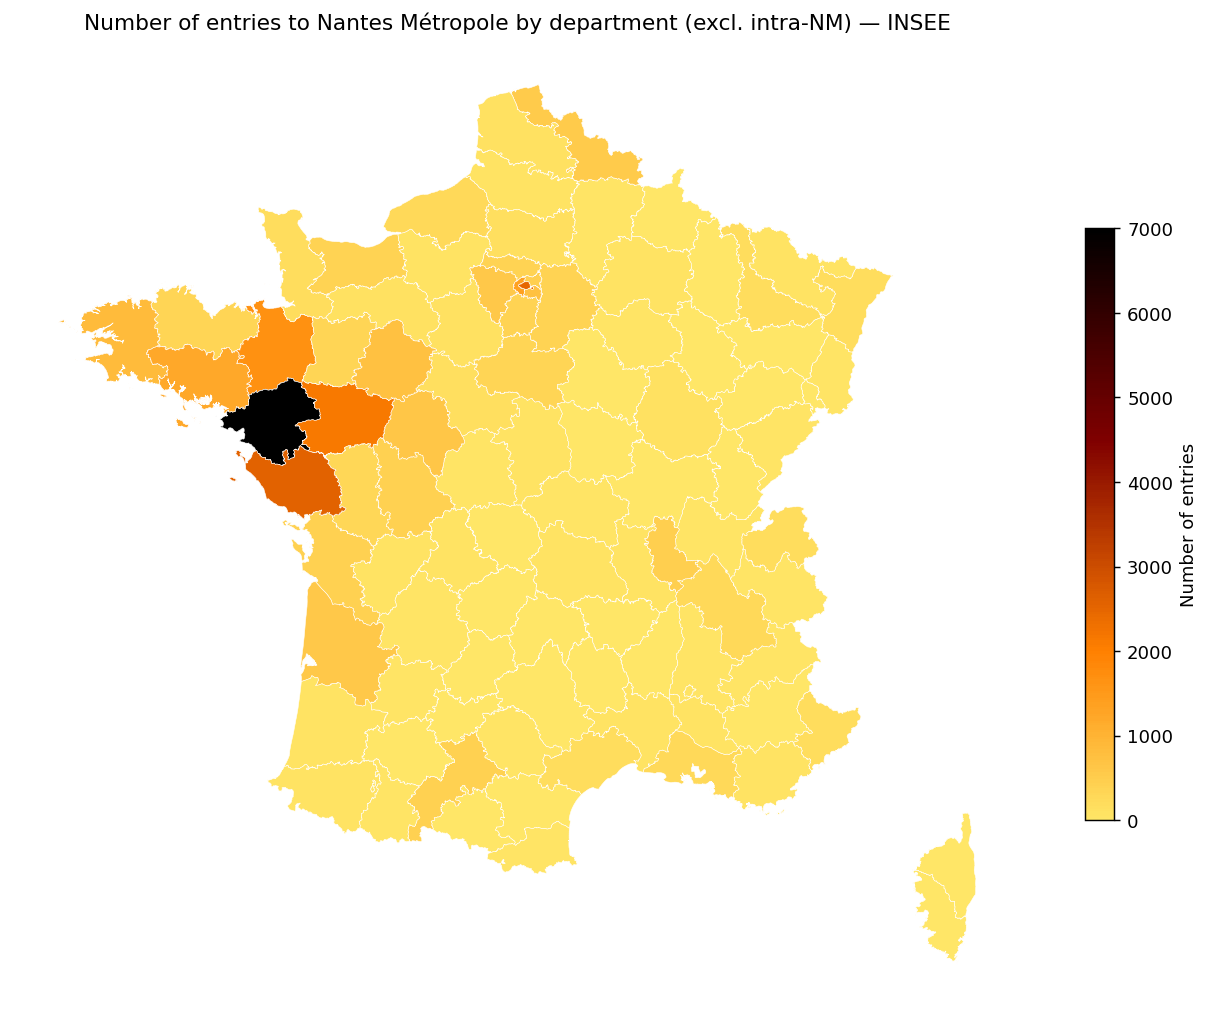

In [11]:
# Inbound moves excl. intra-NM: DCRAN not in NM and is a valid commune code
# Loire-Atlantique (44) is included and coloured by its actual volume
strict_enter_valid = NM_enter_strict[NM_enter_strict['DCRAN'].str.match(r'^\d{5}$', na=False) |NM_enter_strict['DCRAN'].str.match(r'^2[AB]\d{3}$', na=False)].copy()
strict_enter_valid['dept_origin'] = strict_enter_valid['DCRAN'].str[:2]
# Corsica 2A/2B
strict_enter_valid.loc[strict_enter_valid['DCRAN'].str.startswith('2A'), 'dept_origin'] = '2A'
strict_enter_valid.loc[strict_enter_valid['DCRAN'].str.startswith('2B'), 'dept_origin'] = '2B'

entries_dept = (strict_enter_valid.groupby('dept_origin')['IPONDI'].sum().reset_index().rename(columns={'dept_origin': 'code', 'IPONDI': 'nb_entries'}))
gdf_entries_dept = gdf_depts.merge(entries_dept, on='code', how='left')
gdf_entries_dept['nb_entries'] = gdf_entries_dept['nb_entries'].fillna(0)

fig, ax = plt.subplots(figsize=(10, 8))
gdf_entries_dept.plot(column='nb_entries', cmap=NM_CMAP, ax=ax, legend=True, vmax=7000,
    legend_kwds={'label': 'Number of entries', 'orientation': 'vertical', 'shrink': 0.6}, edgecolor='white', linewidth=0.3)
ax.set_axis_off(); ax.set_title('Number of entries to Nantes Métropole by department (excl. intra-NM) — INSEE', fontsize=12)
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/entries_dept_INSEE.png', dpi=150, bbox_inches='tight'); plt.show()

### 8b. Outbound Flows from NM by Department (excl. Intra-NM)

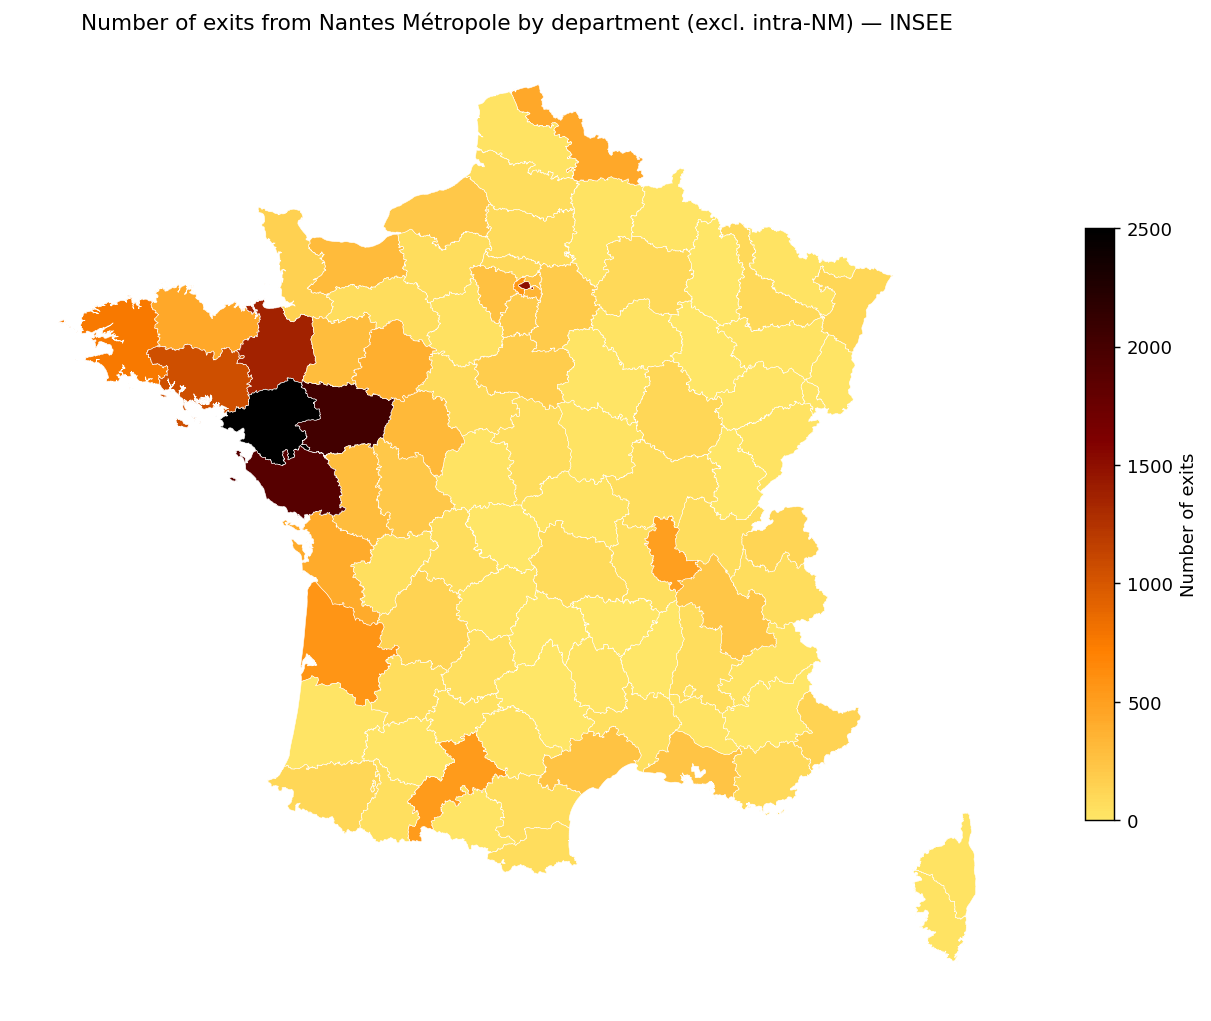

In [12]:
strict_leave_valid = NM_leave_strict[NM_leave_strict['COMMUNE'].str.match(r'^\d{5}$', na=False) | NM_leave_strict['COMMUNE'].str.match(r'^2[AB]\d{3}$', na=False)].copy()
strict_leave_valid['dept_destination'] = strict_leave_valid['COMMUNE'].str[:2]
strict_leave_valid.loc[strict_leave_valid['COMMUNE'].str.startswith('2A'), 'dept_destination'] = '2A'
strict_leave_valid.loc[strict_leave_valid['COMMUNE'].str.startswith('2B'), 'dept_destination'] = '2B'

exits_dept = (strict_leave_valid.groupby('dept_destination')['IPONDI'].sum().reset_index().rename(columns={'dept_destination': 'code', 'IPONDI': 'nb_exits'}))
gdf_exits_dept = gdf_depts.merge(exits_dept, on='code', how='left')
gdf_exits_dept['nb_exits'] = gdf_exits_dept['nb_exits'].fillna(0)

fig, ax = plt.subplots(figsize=(10, 8))
gdf_exits_dept.plot(column='nb_exits', cmap=NM_CMAP, ax=ax, legend=True, vmax=2500,
    legend_kwds={'label': 'Number of exits', 'orientation': 'vertical', 'shrink': 0.6}, edgecolor='white', linewidth=0.3)
ax.set_axis_off(); ax.set_title('Number of exits from Nantes Métropole by department (excl. intra-NM) — INSEE', fontsize=12)
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/exits_dept_INSEE.png', dpi=150, bbox_inches='tight'); plt.show()

## 9. France by Commune: Outbound Flows excl. Intra-NM

Destination of individuals leaving Nantes Métropole, at the commune level.


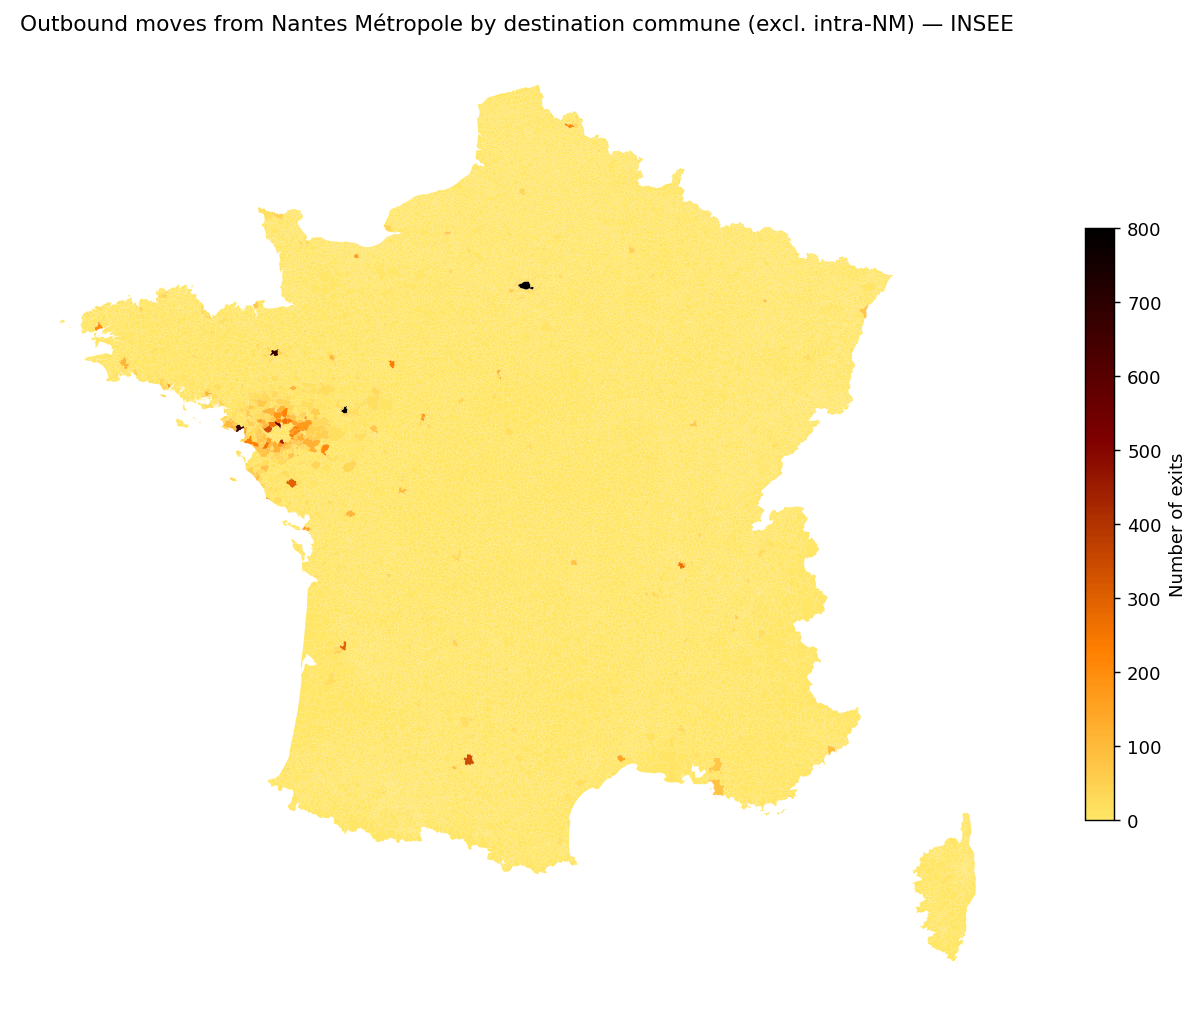

In [13]:
# Outbound moves to other communes in France
exits_commune = (NM_leave_strict.groupby('COMMUNE')['IPONDI'].sum().reset_index().rename(columns={'COMMUNE': 'code', 'IPONDI': 'nb_exits'}))

gdf_exits_comm = gdf_communes.merge(exits_commune, on='code', how='left')
gdf_exits_comm['nb_exits'] = gdf_exits_comm['nb_exits'].fillna(0)

fig, ax = plt.subplots(figsize=(10, 8))
gdf_exits_comm.plot(column='nb_exits', cmap=NM_CMAP, ax=ax, legend=True, vmax=800,
    legend_kwds={'label': 'Number of exits', 'orientation': 'vertical', 'shrink': 0.6}, edgecolor='none')
ax.set_axis_off(); ax.set_title('Outbound moves from Nantes Métropole by destination commune (excl. intra-NM) — INSEE', fontsize=12)
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/exits_commune_INSEE.png', dpi=150, bbox_inches='tight'); plt.show()

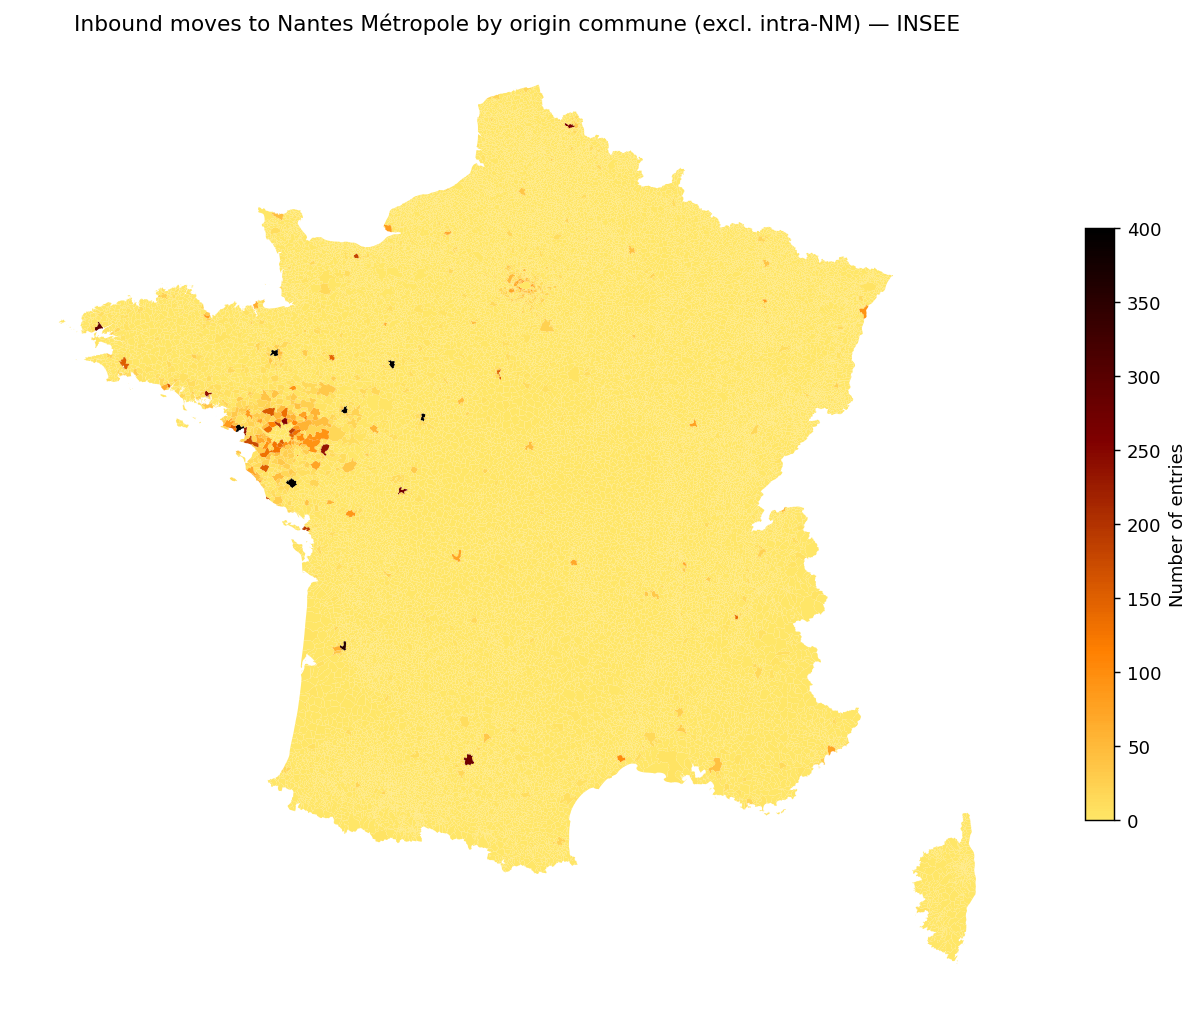

In [14]:
# Inbound moves from other communes in France
entries_commune = (NM_enter_strict.groupby('DCRAN')['IPONDI'].sum().reset_index().rename(columns={'DCRAN': 'code', 'IPONDI': 'nb_entries'}))

gdf_entries_comm = gdf_communes.merge(entries_commune, on='code', how='left')
gdf_entries_comm['nb_entries'] = gdf_entries_comm['nb_entries'].fillna(0)

fig, ax = plt.subplots(figsize=(10, 8))
gdf_entries_comm.plot(column='nb_entries', cmap=NM_CMAP, ax=ax, legend=True, vmax=400,
    legend_kwds={'label': 'Number of entries', 'orientation': 'vertical', 'shrink': 0.6}, edgecolor='none')
ax.set_axis_off(); ax.set_title('Inbound moves to Nantes Métropole by origin commune (excl. intra-NM) — INSEE', fontsize=12)
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/entries_commune_INSEE.png', dpi=150, bbox_inches='tight'); plt.show()

## 10. Attractivity Ratio by Commune (Intra-NM)

**Ratio = intra-NM entries / intra-NM exits** for each commune.  
A ratio > 1 indicates net attractiveness (more arrivals than departures in internal flows).


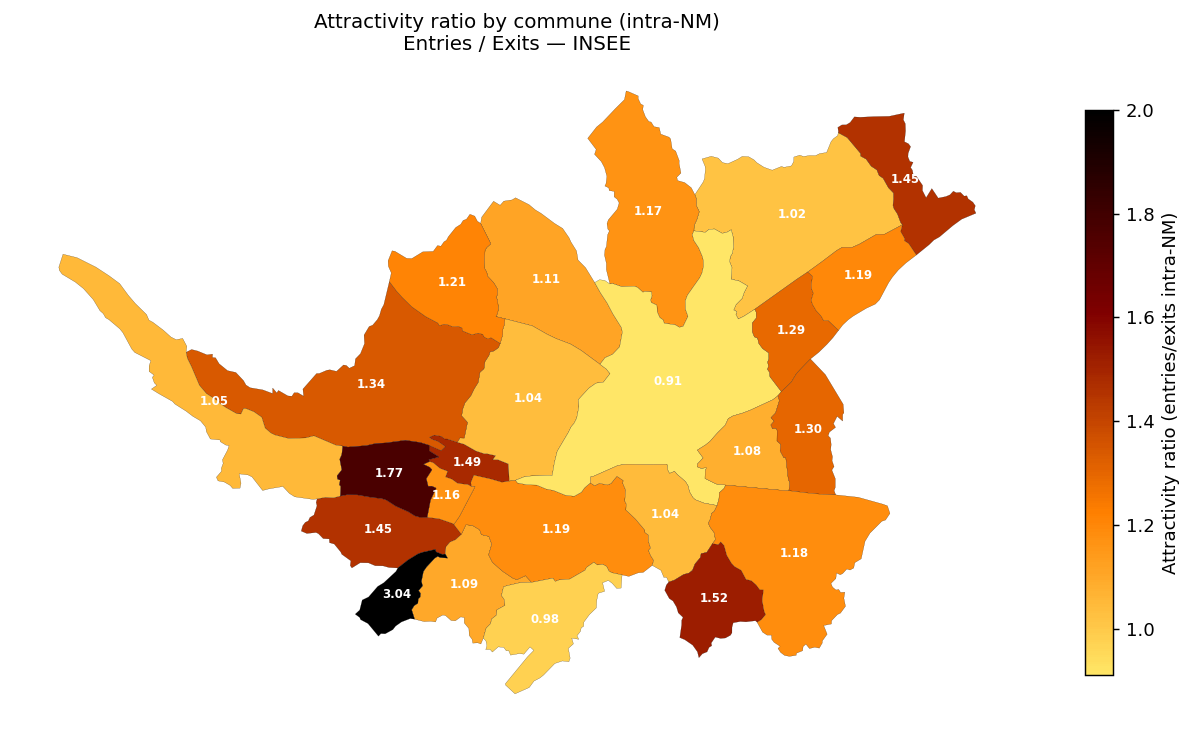

                     name  entries_intra  exits_intra    ratio
                   Nantes   33808.400549 37101.291333 0.911246
   Saint-Aignan-Grandlieu     125.734302   128.665828 0.977216
                Carquefou    1513.154853  1483.412255 1.020050
           Saint-Herblain    4469.761424  4287.767534 1.042445
                     Rezé    3619.584996  3464.491186 1.044767
              Le Pellerin     345.000000   328.375008 1.050628
Saint-Sébastien-sur-Loire    2138.607742  1971.850892 1.084569
                   Bouaye     430.000000   392.820545 1.094647
                  Orvault    2078.533888  1869.337272 1.111910
              La Montagne     526.154678   452.391945 1.163051
    La Chapelle-sur-Erdre    1421.771769  1218.311134 1.167002
                   Vertou    1604.293201  1353.920969 1.184924
               Bouguenais    1698.739430  1432.142195 1.186153
        Thouaré-sur-Loire     905.000000   758.882593 1.192543
                  Sautron     627.592995   517.900636 1

In [15]:
# Prepare per-commune NM data (intra-NM flows only)
entries_intra_nm = NM_intra.groupby('COMMUNE')['IPONDI'].sum().reset_index()
entries_intra_nm.columns = ['code', 'entries_intra']
exits_intra_nm   = NM_intra.groupby('DCRAN')['IPONDI'].sum().reset_index()
exits_intra_nm.columns   = ['code', 'exits_intra']

intra_stats = pd.DataFrame({'code': list(NM_CODES)})
intra_stats = intra_stats.merge(entries_intra_nm, on='code', how='left')\
                          .merge(exits_intra_nm,   on='code', how='left').fillna(0)
intra_stats['ratio'] = intra_stats['entries_intra'] / intra_stats['exits_intra'].replace(0, np.nan)
intra_stats['name']  = intra_stats['code'].map(NM_COMMUNES)

# Merge with geodataframe
gdf_nm_ratio = gdf_nm.merge(intra_stats, on='code', how='left')

fig, ax = plt.subplots(figsize=(10, 9))
gdf_nm_ratio.plot(column='ratio', cmap=NM_CMAP, ax=ax, legend=True, legend_kwds={'label': 'Attractivity ratio (entries/exits intra-NM)',
                 'orientation': 'vertical', 'shrink': 0.5}, edgecolor='black', linewidth=0.1, vmax=2)
# Annotate each commune with its ratio
for _, row in gdf_nm_ratio.iterrows():
    if row.geometry is not None:
        cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
        ratio_txt = f"{row['ratio']:.2f}" if pd.notna(row['ratio']) else ''
        ax.text(cx, cy, ratio_txt, ha='center', va='center', fontsize=6.5,
                color='white', fontweight='bold')

ax.set_axis_off(); ax.set_title("Attractivity ratio by commune (intra-NM)\nEntries / Exits — INSEE", fontsize=11)
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/attractivity_ratio_INSEE.png', dpi=150, bbox_inches='tight'); plt.show()

print(intra_stats[['name','entries_intra','exits_intra','ratio']].sort_values('ratio').to_string(index=False))

## 11. Intra-NM Residential Mobility Flux Matrix

Cell (i, j) = weighted number of persons who moved from commune i to commune j. The **diagonal** represents intra-communal moves.


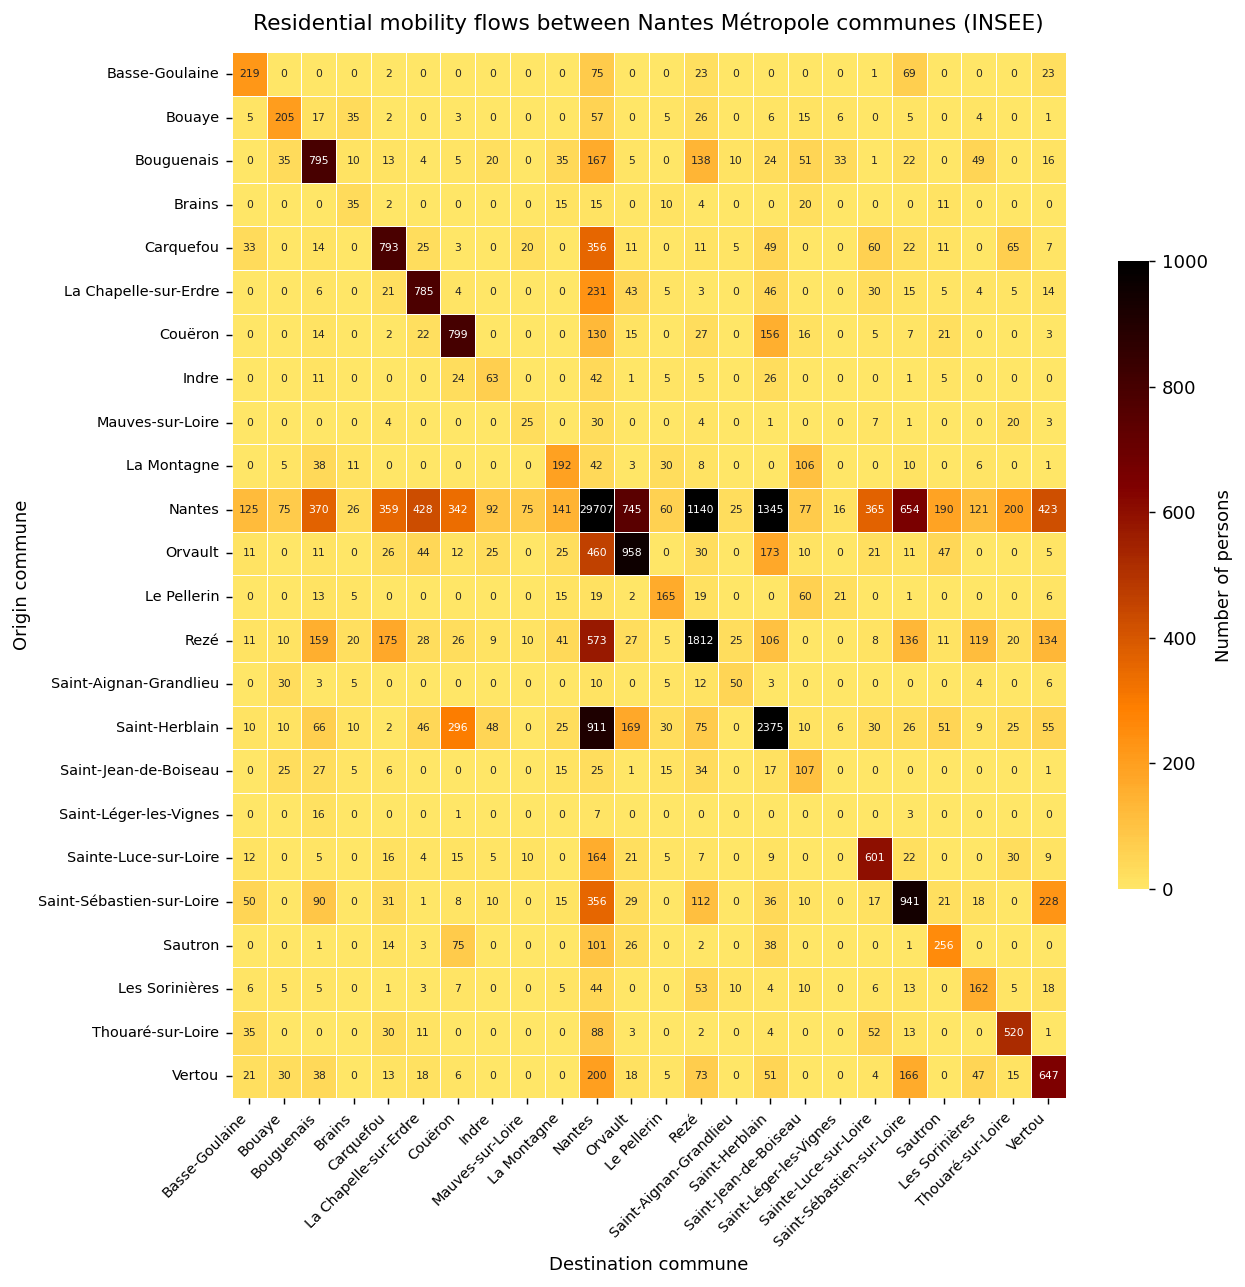

In [16]:
# Pivot table: DCRAN (origin) x COMMUNE (destination)
flux = (NM_intra.groupby(['DCRAN','COMMUNE'])['IPONDI'].sum().reset_index())
flux_pivot = flux.pivot(index='DCRAN', columns='COMMUNE', values='IPONDI').fillna(0)

# Reindex to include all communes in sorted order
all_codes  = sorted(NM_CODES)
flux_pivot = flux_pivot.reindex(index=all_codes, columns=all_codes, fill_value=0)

# Rename axes with commune names
flux_pivot.index   = [NM_COMMUNES.get(c, c) for c in flux_pivot.index]
flux_pivot.columns = [NM_COMMUNES.get(c, c) for c in flux_pivot.columns]

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(flux_pivot, cmap=NM_CMAP, ax=ax, linewidths=0.4, linecolor='white', annot=True, fmt='.0f', 
            annot_kws={'size': 6}, cbar_kws={'label': 'Number of persons', 'shrink': 0.6}, vmax=1000)
ax.set_title('Residential mobility flows between Nantes Métropole communes (INSEE)', fontsize=12, pad=12)
ax.set_xlabel('Destination commune', fontsize=10); ax.set_ylabel('Origin commune', fontsize=10)
plt.xticks(rotation=45, ha='right', fontsize=8); plt.yticks(rotation=0, fontsize=8)
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/flux_matrix_INSEE.png', dpi=150, bbox_inches='tight'); plt.show()

## 12. Origin Distribution by Commune

For each NM commune (as destination), the share of inbound moves is broken down into 6 origin categories:
1. **Intra-communal** : `DCRAN == COMMUNE`
2. **From Nantes** : `DCRAN == '44109'` (unless the target commune is Nantes itself)
3. **Intra-NM** (excl. target commune and excl. Nantes)
4. **Loire-Atlantique excl. NM** : `DCRAN` starts with `44` but outside NM
5. **Île-de-France** : `DCRAN[:2]` in {75,77,78,91,92,93,94,95}
6. **Rest of France** (incl. abroad `99999`)


In [17]:
def cat_origin(dcran, target):
    """Categorise the origin DCRAN relative to the target commune."""
    if not isinstance(dcran, str) or len(dcran) < 2:
        return 'prop_france_excl_idf_excl_44'
    if dcran == target:
        return 'prop_intracommune'
    if dcran == '44109' and target != '44109':
        return 'prop_nantes'
    if dcran in NM_CODES:
        return 'prop_nm_excl_commune_excl_nantes'
    dept = dcran[:2] if dcran[0].isdigit() else dcran[:2]
    if dcran.startswith('2A') or dcran.startswith('2B'):
        dept = dcran[:2]
    if dept == '44':
        return 'prop_44_excl_nm'
    if dept in IDF_DEPTS:
        return 'prop_idf'
    return 'prop_france_excl_idf_excl_44'

CATS   = ['prop_intracommune','prop_nantes','prop_nm_excl_commune_excl_nantes','prop_44_excl_nm','prop_idf','prop_france_excl_idf_excl_44']
COLORS = ['#4ab148', '#0a693f', '#377db8', '#14558b', '#ff7f00', '#e51a1d']
LABELS = ['Intra-communal','From Nantes','Intra-NM (excl. commune, excl. Nantes)', 'Loire-Atlantique excl. NM','Île-de-France','Rest of France / Abroad']

prop_rows = []
for code, name in sorted(NM_COMMUNES.items(), key=lambda x: x[1]):
    sub = NM_enter[NM_enter['COMMUNE'] == code].copy()
    if sub.empty:
        continue
    sub['cat'] = sub['DCRAN'].apply(lambda d: cat_origin(d, code))
    total = sub['IPONDI'].sum()
    row = {'commune': name}
    for cat in CATS:
        row[cat] = sub.loc[sub['cat'] == cat, 'IPONDI'].sum() / total * 100
    prop_rows.append(row)

prop_df = pd.DataFrame(prop_rows).set_index('commune')[CATS].fillna(0)
prop_df.round(1).head()

,prop_intracommune,prop_nantes,prop_nm_excl_commune_excl_nantes,prop_44_excl_nm,prop_idf,prop_france_excl_idf_excl_44
commune,,,,,,
Basse-Goulaine,24.2,13.8,21.4,11.5,11.4,17.7
Bouaye,35.0,12.8,25.6,11.1,0.9,14.5
Bouguenais,34.0,15.8,22.9,7.3,2.6,17.4
Brains,14.7,10.7,42.8,15.0,0.0,16.8
Carquefou,28.7,13.0,13.1,13.4,8.1,23.7


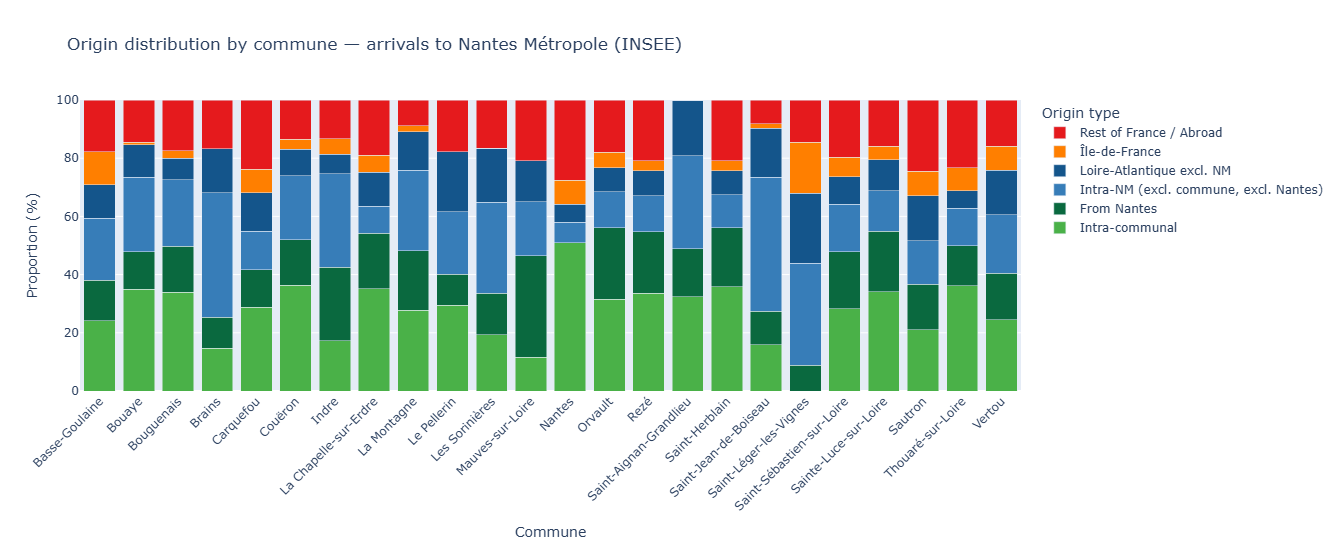

In [18]:
fig_prov = go.Figure()
for cat, color, label in zip(CATS, COLORS, LABELS):
    fig_prov.add_trace(go.Bar(name=label, x=prop_df.index.tolist(), y=prop_df[cat].tolist(), marker_color=color))
fig_prov.update_layout(barmode='stack', title='Origin distribution by commune — arrivals to Nantes Métropole (INSEE)',
    xaxis_title='Commune', yaxis_title='Proportion (%)', yaxis=dict(range=[0, 100]), legend_title='Origin type',
    xaxis=dict(tickangle=-45), width=1100, height=550)

fig_prov.write_html('origin_distribution.html')
fig_prov.show()